Here you can find problem b and e.

## Problem b)

In [338]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read data from csv-file and print headers
data = pd.read_csv('compas-scores-two-years.csv')

data.keys()

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [218]:
data[['screening_date', 'r_offense_date']][~data['r_offense_date'].isna()][:20]

,screening_date,r_offense_date
1,2013-01-27,2013-07-05
2,2013-04-14,2013-06-16
6,2014-02-19,2014-03-31
9,2013-11-04,2015-01-06
11,2013-10-03,2014-02-08
14,2013-10-30,2014-06-03
15,2014-06-03,2014-06-25
18,2013-11-17,2014-07-16
19,2014-11-15,2015-04-27
20,2014-05-02,2014-05-03


In [219]:
"""filter = (data['two_year_recid'] != data['is_recid']) & ~data['vr_charge_desc'].isna()
filter = data['violent_recid'] != data['is_violent_recid']
#print(data['vr_offense_date'][~data['vr_offense_date'].isna()] - data['v_screening_date'][~data['vr_offense_date'].isna()])
print(data['v_screening_date'])
filter = (data['is_violent_recid'] == 1) & (data['two_year_recid'] == 0)
data[['two_year_recid', 'is_recid','vr_case_number', 'is_violent_recid', 'vr_charge_desc']][filter]"""

"filter = (data['two_year_recid'] != data['is_recid']) & ~data['vr_charge_desc'].isna()\nfilter = data['violent_recid'] != data['is_violent_recid']\n#print(data['vr_offense_date'][~data['vr_offense_date'].isna()] - data['v_screening_date'][~data['vr_offense_date'].isna()])\nprint(data['v_screening_date'])\nfilter = (data['is_violent_recid'] == 1) & (data['two_year_recid'] == 0)\ndata[['two_year_recid', 'is_recid','vr_case_number', 'is_violent_recid', 'vr_charge_desc']][filter]"

In [220]:
"""string = '2013-12-02'
year = int(string[:4])
mon = int(string[5:7])
day = int(string[8:10])
print(f'{year} {mon} {day}')

print(int(string[:4]))

string2 = str(int(string[3]) + 2)
#string[3] = string2

print(string2)"""

"string = '2013-12-02'\nyear = int(string[:4])\nmon = int(string[5:7])\nday = int(string[8:10])\nprint(f'{year} {mon} {day}')\n\nprint(int(string[:4]))\n\nstring2 = str(int(string[3]) + 2)\n#string[3] = string2\n\nprint(string2)"

In [221]:
# We demand that the crime was committed within 30 days of COMPAS Screening for data quality:

data = data[(data["days_b_screening_arrest"] <= 30) & (data["days_b_screening_arrest"] >= -30)] 

# Extracting relevant columns:
data = data[['compas_screening_date', 'sex', 'age', 'age_cat', 'race', 'decile_score', 'score_text', 'is_violent_recid', 'v_score_text','two_year_recid']]

In [ ]:
# Create filters
false_pos = (data['decile_score'] > 4) & (data['two_year_recid'] == 0)
false_neg = (data['decile_score'] <= 4) & (data['two_year_recid'] == 1)

true_pos = (data['decile_score'] > 4) & (data['two_year_recid'] == 1)
true_neg = (data['decile_score'] <= 4) & (data['two_year_recid'] == 0)

"""# Equally, for violent recidivism

false_pos_v = (data['decile_score'] > 4) & (data['two_year_recid'] == 0)
false_neg_v = (data['decile_score'] <= 4) & (data['two_year_recid'] == 1)

true_pos_v = (data['decile_score'] > 4) & (data['two_year_recid'] == 1)
true_neg_v = (data['decile_score'] <= 4) & (data['two_year_recid'] == 0)"""

In [223]:
print(f'Rate of false positives: {round(100*len(data[false_pos])/len(data), 1)}%')
print(f'Rate of false negatives: {round(100*len(data[false_neg])/len(data), 1)}%')
print(f'Rate of true positives: {round(100*len(data[true_pos])/len(data), 1)}%')
print(f'Rate of true negatives: {round(100*len(data[true_neg])/len(data), 1)}%')

Rate of false positives: 16.5%
Rate of false negatives: 17.4%
Rate of true positives: 28.1%
Rate of true negatives: 38.0%


We now want to find the rate of recidivism given that the assigned COMPAS score is 'high' (which in the dataset corresponds to medium-high in 'score_text', or a decile value of 5 or above). This can be written as $P(recid|high)$. We firstly do this for the entire dataset without filtering for characteristics. This value is found by looking at the number of true positives divided by the number of positives (positive = high).

In [224]:
high = (data['decile_score'] > 4)
print(f'Rate of recidivism, given high COMPAS score: {round(100*len(data[true_pos])/len(data[high]), 1)}%')

Rate of recidivism, given high COMPAS score: 63.0%


In [225]:
all = (data['sex'] == data['sex'])
male = (data['sex'] == 'Male')
female = (data['sex'] == 'Female')
white = (data['race'] == 'Caucasian')
black = (data['race'] == 'African-American')

filters = [(all, 'all'), (male, 'male'), (female, 'female'), (white, 'white'), (black, 'black')]
print()
for filter, name in filters:
    print(f'Rate of recidivism, high COMPAS score, {name}: {round(100*len(data[true_pos & filter])/len(data[high & filter]), 1)}%')


Rate of recidivism, high COMPAS score, all: 63.0%
Rate of recidivism, high COMPAS score, male: 65.4%
Rate of recidivism, high COMPAS score, female: 51.7%
Rate of recidivism, high COMPAS score, white: 59.5%
Rate of recidivism, high COMPAS score, black: 65.0%


## Problem e)

To create a random forest, we have to randomly split the available data into a training set and a test set. The former is used to create the model and the latter to verify its accuracy.

We begin by quantifying the string columns we are to use, namely the columns for sex and charge degree.

In [ ]:
data = pd.read_csv('compas-scores-two-years.csv')
filter = data['sex'] == 'Female'

data.loc[~filter, 'sex'] = 0.0 #males
data.loc[filter, 'sex'] = 1.0 #females

filter = data['c_charge_degree'] == 'F'
data.loc[filter, 'c_charge_degree'] = 1.0 # Felony

filter = data['c_charge_degree'] == 'M'
data.loc[filter, 'c_charge_degree'] = 0.0 # Misdemeanor

data['priors_count'] = np.array(data['priors_count'], dtype=float) #converting integers to floats for the final Partial Dependence plot
data['age'] = np.array(data['age'], dtype=float) #converting integers to floats for the final Partial Dependence plot

data[['age','sex','priors_count','c_charge_degree']] #

,age,sex,priors_count,c_charge_degree
0,69.0,0.0,0.0,1.0
1,34.0,0.0,0.0,1.0
2,24.0,0.0,4.0,1.0
3,23.0,0.0,1.0,1.0
4,43.0,0.0,2.0,1.0
...,...,...,...,...
7209,23.0,0.0,0.0,1.0
7210,23.0,0.0,0.0,1.0
7211,57.0,0.0,0.0,1.0
7212,33.0,1.0,3.0,0.0


Since the forests will have a varying degree of predictive accuracy, we make 50 forests to estimate the average accuracy. <br><br>
_Note: By a number of manual iterations it looks as though n_estimators above 100 does not significantly impact the accuracy of the forest._

In [399]:
from sklearn.model_selection import train_test_split
# Random forest:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

N = 50 # number of iterations

X = data[['age','sex','priors_count','c_charge_degree']] # Used variables in model
Y = data['two_year_recid'] # 'Prediction variable'

# Splitting into train and test sets:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.5) #with test_size = 0.5, we get equally large sets

tot_acc = 0
tot_prec = 0
tot_rec = 0
tot_cm = 0
for i in range(N):
    forest = RandomForestClassifier(n_estimators = 100, max_features='sqrt')
    forest.fit(x_train, y_train)

    pred = forest.predict(x_test)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)

    tot_acc += acc
    tot_prec += prec
    tot_rec += rec
    tot_cm += cm

"""print(f"Average accuracy of {N} forests: {round(100*tot_acc/N,1)} %")
print(f"Average precision of {N} forests: {round(100*tot_prec/N,1)} %")
print(f"Average recall of {N} forests: {round(100*tot_rec/N,1)} %")
print()"""
print(f"Average confusion matrix values of {N} forests:")
print(f"True positives: {round(100*tot_cm[1][1]/N/len(x_test), 1)} %")
print(f"True negatives: {round(100*tot_cm[0][0]/N/len(x_test), 1)} %")
print(f"False positives: {round(100*tot_cm[0][1]/N/len(x_test), 1)} %")
print(f"False negatives: {round(100*tot_cm[1][0]/N/len(x_test), 1)} %")

Average confusion matrix values of 50 forests:
True positives: 25.9 %
True negatives: 38.1 %
False positives: 17.4 %
False negatives: 18.7 %


From here on we use the forest created in the final iteration of the loop. As we can see from comparing its behavior to that of the average, it is a fairly representable candidate of the average.

In [400]:
"""print(f"Accuracy of final forest: {round(100*acc,1)} %")
print(f"Precision of final forest: {round(100*prec,1)} %")
print(f"Recall of final forest: {round(100*rec,1)} %")
print()"""
print(f"Confusion matrix values of final forest:")
print(f"True positives: {round(100*cm[1][1]/len(x_test), 1)} %")
print(f"True negatives: {round(100*cm[0][0]/len(x_test), 1)} %")
print(f"False positives: {round(100*cm[0][1]/len(x_test), 1)} %")
print(f"False negatives: {round(100*cm[1][0]/len(x_test), 1)} %")

Confusion matrix values of final forest:
True positives: 25.6 %
True negatives: 37.9 %
False positives: 17.5 %
False negatives: 19.0 %


We shall now filter the test set based on race and see how the values differ.

In [401]:
index_b = data.index[data['race'] == 'African-American']
index_w = data.index[data['race'] == 'Caucasian']

x_test_black = x_test_df[x_test_df.index.isin(index_b)]
y_test_black = y_test_df[y_test_df.index.isin(index_b)]
x_test_white = x_test_df[x_test_df.index.isin(index_w)]
y_test_white = y_test_df[y_test_df.index.isin(index_w)]

In [402]:
pred = forest.predict(x_test_black)
acc = accuracy_score(y_test_black, pred)
prec = precision_score(y_test_black, pred)
rec = recall_score(y_test_black, pred)
cm = confusion_matrix(y_test_black, pred)

false_pos_b = cm[0][1]/len(x_test_black)
false_neg_b = cm[1][0]/len(x_test_black)

print("Values for African-American screening:")
print("--------------------------------------------")
"""print(f"Accuracy of forest: {round(100*acc,1)}%")
print(f"Precision of forest: {round(100*prec,1)}%")
print(f"Recall of forest: {round(100*rec,1)}%")
print()
print(f"Confusion matrix values:")"""
print(f"True positives: {round(100*cm[1][1]/len(x_test_black), 1)}% ({cm[1][1]})")
print(f"True negatives: {round(100*cm[0][0]/len(x_test_black), 1)}% ({cm[0][0]})")
print(f"False positives: {round(100*cm[0][1]/len(x_test_black), 1)}% ({cm[0][1]})")
print(f"False negatives: {round(100*cm[1][0]/len(x_test_black), 1)}% ({cm[1][0]})")

Values for African-American screening:
--------------------------------------------
True positives: 36.5% (683)
True negatives: 33.4% (625)
False positives: 14.0% (262)
False negatives: 16.1% (301)


In [403]:
pred = forest.predict(x_test_white)
acc = accuracy_score(y_test_white, pred)
prec = precision_score(y_test_white, pred)
rec = recall_score(y_test_white, pred)
cm = confusion_matrix(y_test_white, pred)

false_pos_w = cm[0][1]/len(x_test_white)
false_neg_w = cm[1][0]/len(x_test_white)

print("Values for Caucasian screening:")
print("--------------------------------------------")
"""print(f"Accuracy of forest: {round(100*acc,1)}%")
print(f"Precision of forest: {round(100*prec,1)}%")
print(f"Recall of forest: {round(100*rec,1)}%")
print()
print(f"Confusion matrix values:")"""
print(f"True positives: {round(100*cm[1][1]/len(x_test_white), 1)}% ({cm[1][1]})")
print(f"True negatives: {round(100*cm[0][0]/len(x_test_white), 1)}% ({cm[0][0]})")
print(f"False positives: {round(100*cm[0][1]/len(x_test_white), 1)}% ({cm[0][1]})")
print(f"False negatives: {round(100*cm[1][0]/len(x_test_white), 1)}% ({cm[1][0]})")

Values for Caucasian screening:
--------------------------------------------
True positives: 24.0% (294)
True negatives: 47.0% (577)
False positives: 11.5% (141)
False negatives: 17.5% (215)


As we can see, there are a lot more true positives for African-Americans, as compared to Caucasians - almost double! Furthermore, the amount of true negatives are a lot higher for Caucasians.
<br><br>
On the other hand, the rates of false negatives and positives are closer in value across ethnicity. This being said, there is a higher rate of false positives for African-Americans simultaneously as there is a higher rate of false negatives for Caucasians. This suggests that there is a bias towards stricter predictions for African-Americans even though the model doesn't use ethinicity as a variable.

In [406]:
print(f"There is a {round(100*false_pos_b/false_pos_w - 100, 1)}% higher rate of false positives for African-Americans compared to Caucasians")
print(f"There is a {round(100*false_neg_w/false_neg_b - 100, 1)}% higher rate of false negatives for Caucasians compared to African-Americans")

There is a 21.9% higher rate of false positives for African-Americans compared to Caucasians
There is a 8.9% higher rate of false negatives for Caucasians compared to African-Americans


This suggests that our model is intrinsically unjust, predicting both Caucasians as low-risk and African-Americans as high-risk too often.

Text(0.5, 1.0, 'Feature Importance')

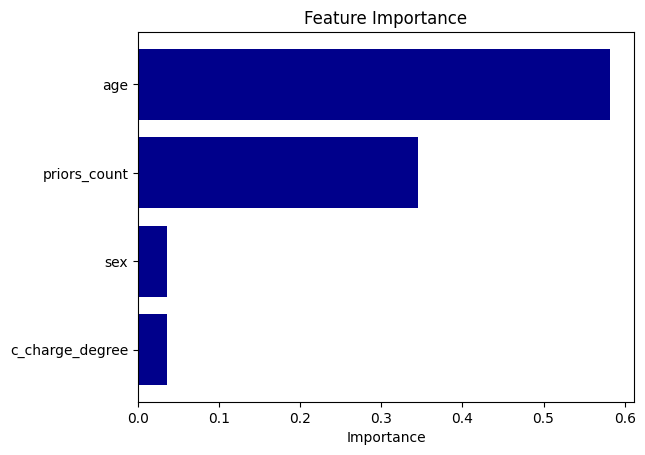

In [407]:
names = ['Age','Sex','#Priors','Charge degree']
importance = forest.feature_importances_

plt.barh(X.columns[np.argsort(importance)], importance[np.argsort(importance)], color='darkblue')
#plt.yticks(np.arange(len(names)), labels=names)
plt.xlabel('Importance')
plt.title('Feature Importance')

According to our feature importance plot, the model relies the most on the age of the defendant as well as the number of prior charges. The model cares less about their sex and the degree of the charge.

Although the model does not take ethnicity as a variable in its training, we can consider whether prior charges and charge degree can act as proxies for ethnicity through the reality of racial profiling and harsher sentencing for certain ethnicities. If we imagine that count of prior charges is in fact the second best variable to predict recidivism, we are in trouble because the count of charges in our data might be racially biased, and therefore, the 'best' model automatically becomes unjust if we do not actively counter-act the racial bias. This is, however, not a trivial task.

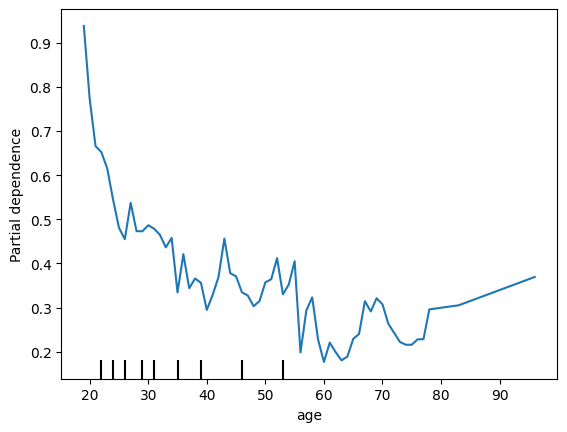

In [408]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(forest, x_test_df, features=['age'])

The model suggests that there is a much higher chance of recidivism at younger ages. With a little bit of a cheeky increase as we go beyond 80 years of age.